# Stochastic SFH Fitting

Full correlated-field SFH with GP latent (D = 135).
Three inference methods compared on the same mock galaxy:

1. **geoVI (NIFTy)** — variational, fast default (~12s)
2. **native_geovi (JIT)** — compile once, then ~12s cached
3. **Ray Tracing** — exact MCMC (Behroozi 2025)

All produce posterior samples, SFH recovery, and corner plots.

In [1]:
import os
import sys
import time
import warnings

os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
proj_root = os.path.abspath(os.path.join(_here, ".."))
os.chdir(proj_root)
sys.path.insert(0, os.path.join(proj_root, "notebooks"))

from tengri import (  # noqa: E402
    Fitter,
    Fixed,
    Model,
    Observation,
    ParamSpec,
    Uniform,
    load_ssp_data,
)
from tengri.models.observation import SpectroscopyConfig  # noqa: E402

from _plot_style import (  # noqa: E402
    COLORS,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

FIGDIR = os.path.join("explore", "figures")
os.makedirs(FIGDIR, exist_ok=True)

## 1. Setup

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5",
)
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
obs = Observation(spectroscopy=SpectroscopyConfig(wave_obs=WAVE_OBS))

## 2. Stochastic model (D = 135)

In [3]:
N_GRID = 128

spec = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.3, 2.0),
    sfh_dpl_tau_gyr=Uniform(1.0, 8.0),
    sfh_dpl_log_peak_sfr=Uniform(0.0, 1.5),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.0),
    dust_slope=Fixed(-0.7),
    sfh_field_psd_sigma=Fixed(1.5),
    sfh_field_psd_tau_myr=Fixed(50.0),
    redshift=Fixed(0.1),
    stochastic=True,
    n_grid=N_GRID,
)
model = Model(spec, ssp_data, observation=obs)
n_phys = len(spec.free_params)
D = n_phys + N_GRID
print(f"{n_phys} physical + {N_GRID} GP latent = D={D}")

7 physical + 128 GP latent = D=135


W0331 20:26:25.408996 29965351 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
/Users/suchethacooray/Projects/diffsed/src/tengri/core/model.py:503: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


In [4]:
key = jax.random.PRNGKey(123)
true_params = spec.sample(key)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=30.0, key=key)

## 3. geoVI — NIFTy fast path (default)

Calls JIT'd primitives from Python. No heavy XLA compile.
2000 posterior samples. Best for single-galaxy fitting.

In [5]:
fitter = Fitter(model, mock.flux_obs, mock.noise)

t0 = time.perf_counter()
result_geovi = fitter.run(
    "geovi", n_iterations=15, n_posterior_samples=2000, verbose=True,
)
t_geovi = time.perf_counter() - t0
n_samples_geovi = len(next(iter(result_geovi.samples.values())))
print(f"\ngeoVI: {t_geovi:.1f}s, {n_samples_geovi} samples")

assuming the specified inverse covariance is diagonal
assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


  init_from='auto' → 'random' (n_seeds=5; random starts are better for multi-seed exploration)
  parallel_seeds=False (auto: cpu backend; sequential is faster on CPU due to early stopping)
geoVI (JIT): 135 params, 200 data points, 15 iterations, 3 samples/iter, 5 seeds
  Seed 1/5: H=137.5, 6 iters
  Seed 2/5: H=91.1, 7 iters
  Seed 3/5: H=93.8, 12 iters
  Seed 4/5: H=87.6, 7 iters
  Seed 5/5: H=96.5, 7 iters
  Drawing 2000 nonlinear posterior samples (JIT geoVI)...


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:2397: UserWarning: Seeds disagree: H = 101.3 ± 18.3 (CV=18%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


  EVI (JIT) complete in 96.2s, 7/15 iterations, 2000 posterior samples

geoVI: 116.8s, 2000 samples


### 3a. geoVI results

In [6]:
result_geovi.summary_table()

'Posterior  method: EVI (JIT)  samples: 2000  wall_time: 96.2s\n──────────────────────────────────────────────────────────────────\n  Parameter                       Median       16%       84%     ESS\n  ────────────────────────────────────────────────────────────────\n  dust_Rv                         3.1000    3.1000    3.1000       —\n  dust_bump_strength              0.0000    0.0000    0.0000       —\n  dust_delta                      0.0000    0.0000    0.0000       —\n  dust_f_obscuration              0.0000    0.0000    0.0000       —\n  dust_slope                     -0.7000   -0.7000   -0.7000       —\n  dust_tau_bc                     0.8485    0.5272    1.2038       —\n  dust_tau_diff                   0.3316    0.2785    0.3885       —\n  met_alpha_fe                    0.0000    0.0000    0.0000       —\n  met_logzsol                    -0.5817   -0.6292   -0.5316       —\n  noise_dof                       0.0000    0.0000    0.0000       —\n  noise_frac_cal              

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_61886/4197635841.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


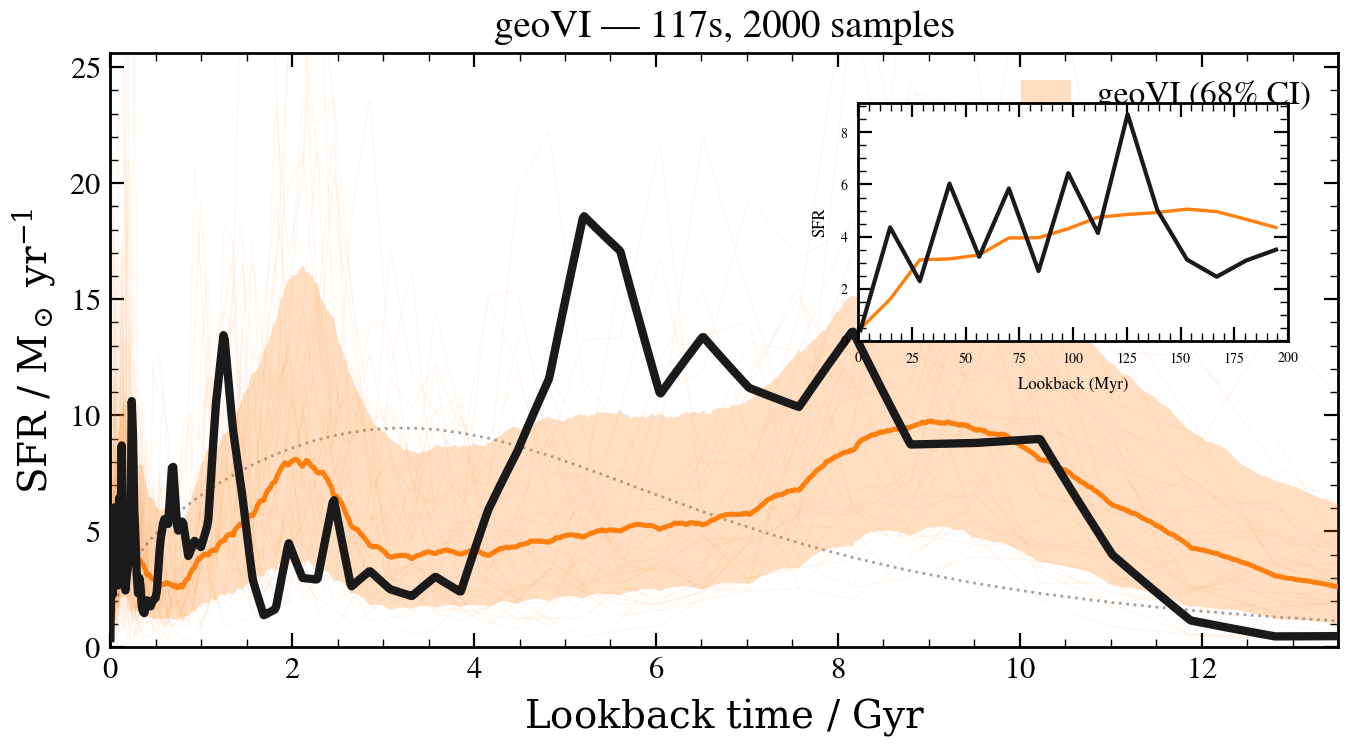

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_sfh(model, result_geovi, true_params=true_params, ax=ax,
         method="geoVI", label="geoVI")
ax.set_title(f"geoVI — {t_geovi:.0f}s, {n_samples_geovi} samples")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_sfh_geovi.png"),
            dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site

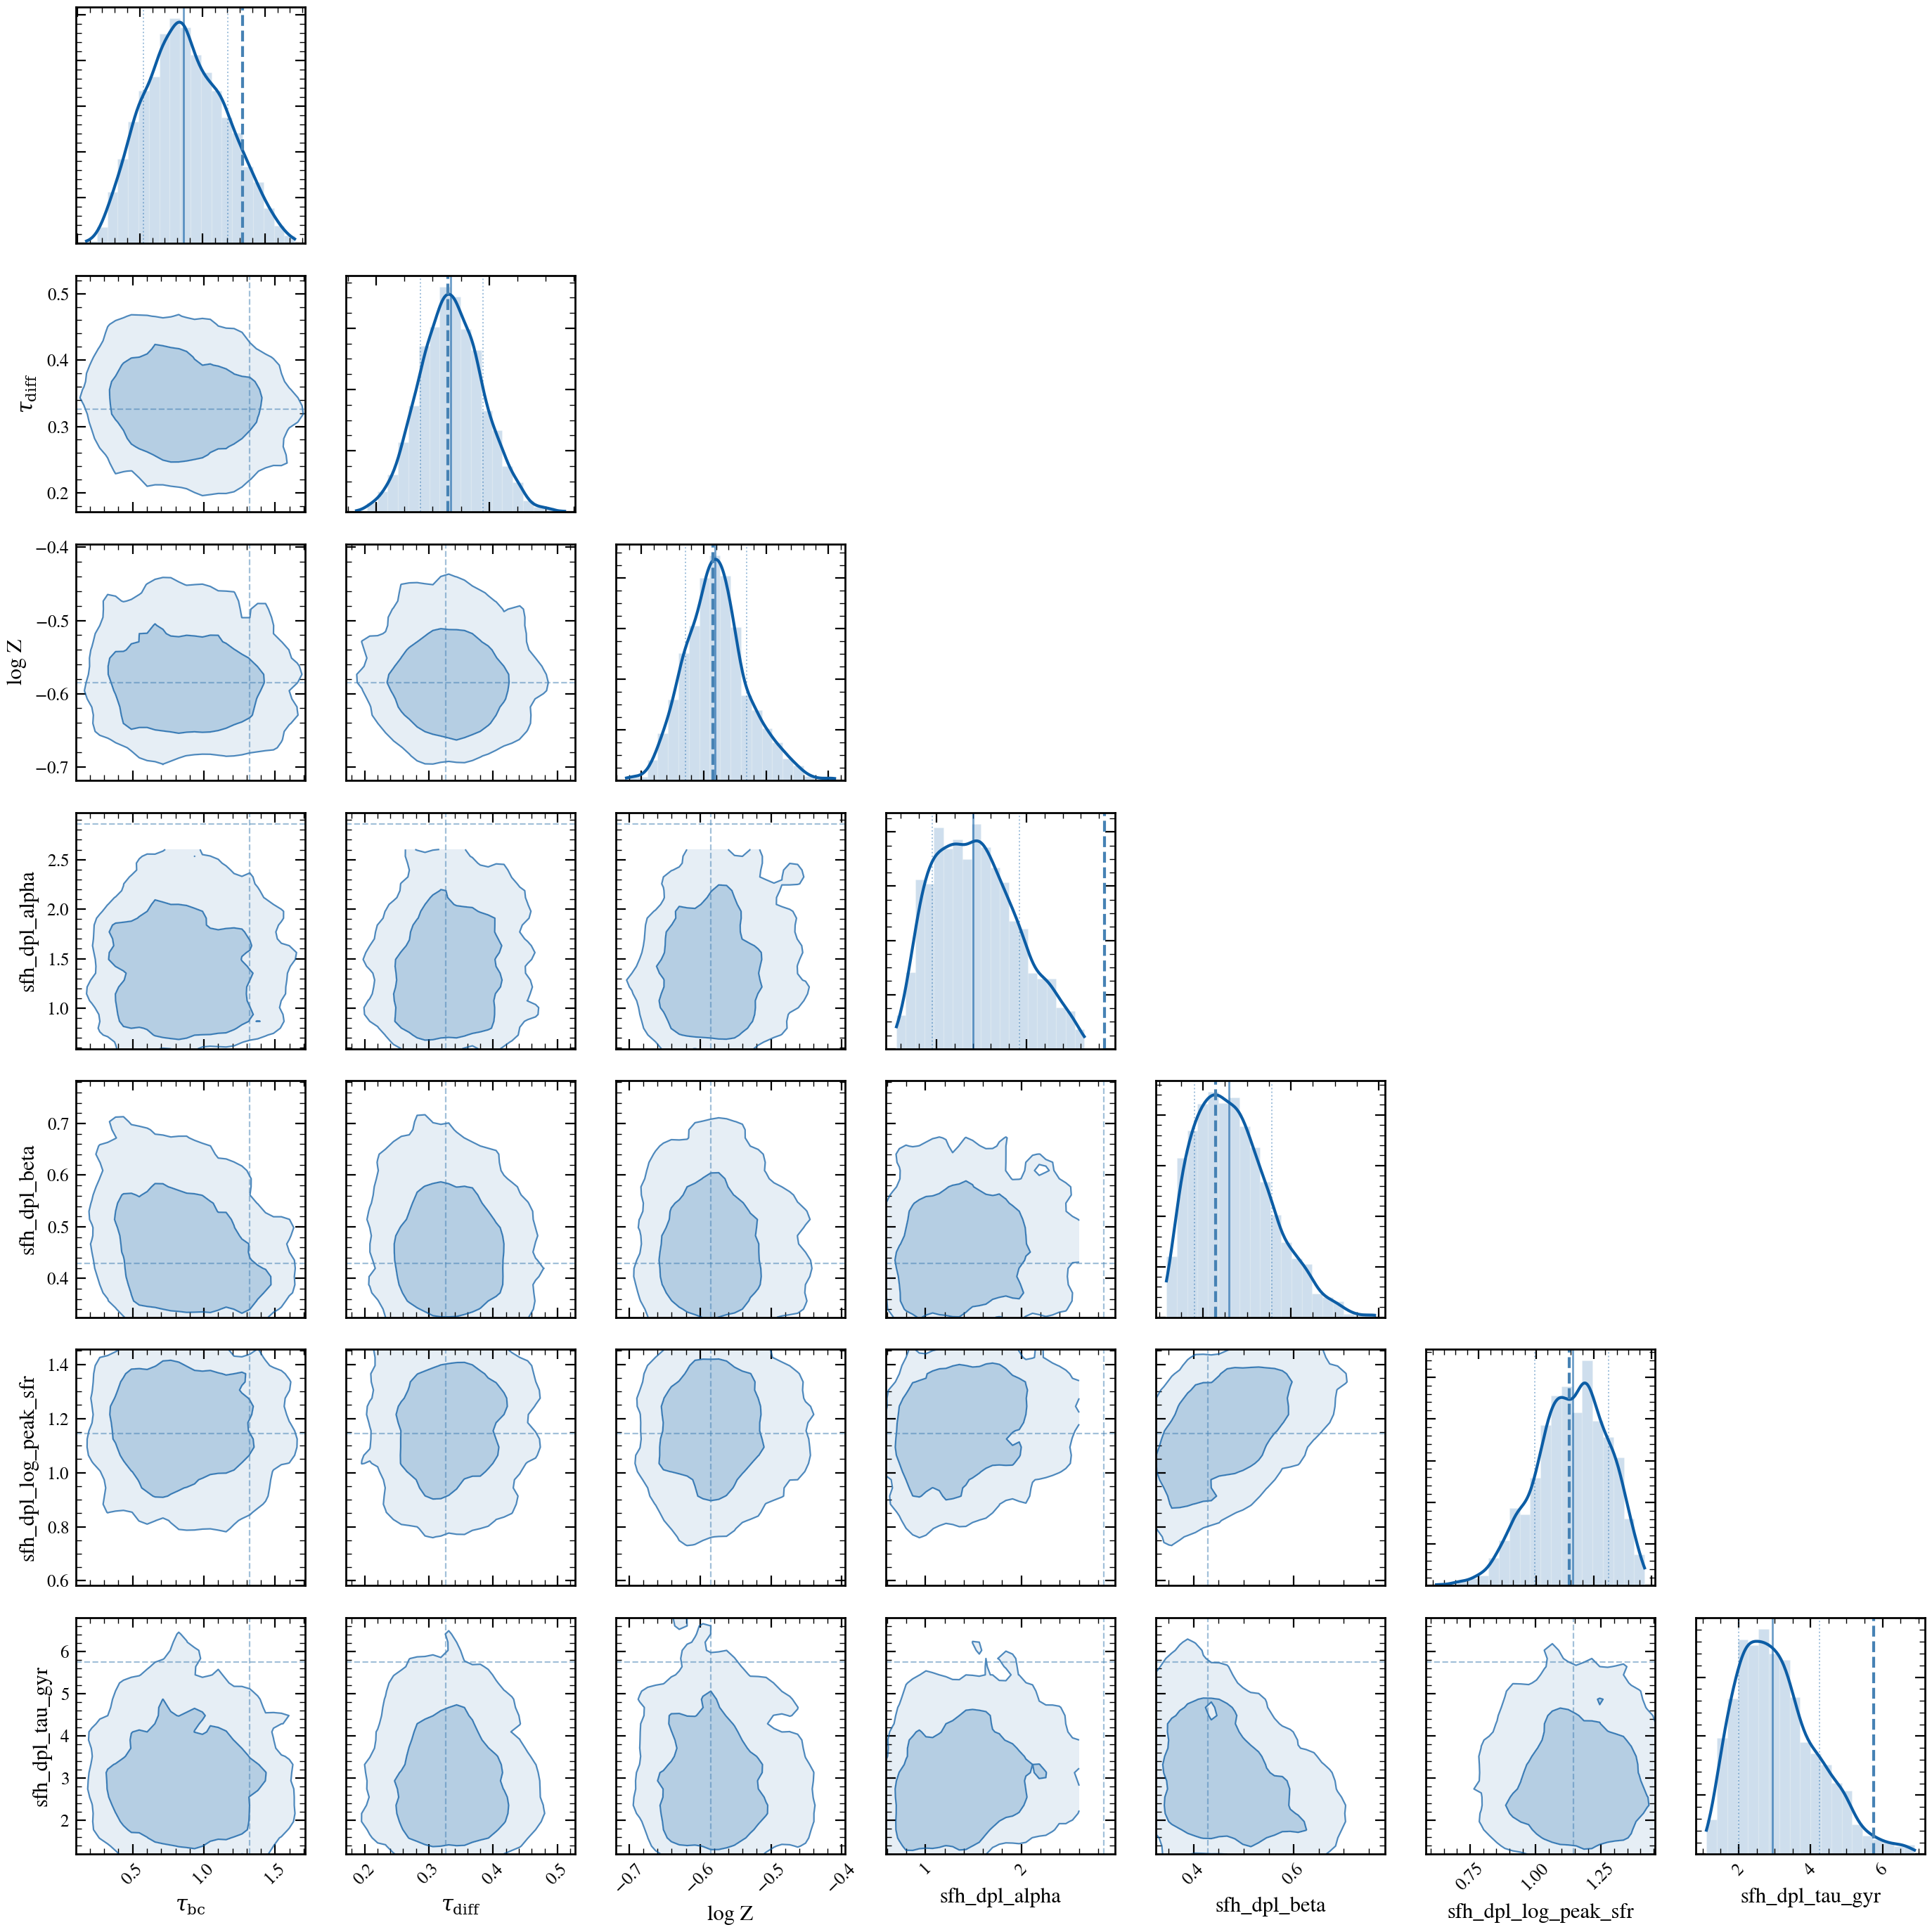

In [8]:
fig = safe_corner(result_geovi, truths=true_params)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "02_corner_geovi.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 4. native_geovi — fully JIT (for batch/vmap)

Entire optimizer compiled into one XLA program.
MAP-initialized (1 seed). 2000 posterior samples.
First call: ~60s (compile). Cached calls: ~12s.

In [9]:
# First call: XLA compilation
t0 = time.perf_counter()
result_native_1 = fitter.run(
    "native_geovi", n_iterations=15, n_seeds=1, verbose=True,
)
t_native_compile = time.perf_counter() - t0
print(f"\nnative_geovi (1st, compile): {t_native_compile:.1f}s")

  init_from='auto' → 'map' (single seed; MAP warmstart)
geoVI (JIT): 135 params, 200 data points, 15 iterations, 3 samples/iter
  MAP warmstart done
  Drawing 2000 nonlinear posterior samples (JIT geoVI)...
  EVI (JIT) complete in 15.3s, 7/15 iterations, 2000 posterior samples

native_geovi (1st, compile): 17.2s


In [10]:
# Second call: XLA cached
t0 = time.perf_counter()
result_native_2 = fitter.run(
    "native_geovi", n_iterations=15, n_seeds=1,
    key=jax.random.PRNGKey(999), verbose=True,
)
t_native_cached = time.perf_counter() - t0
n_samples_native = len(next(iter(result_native_2.samples.values())))
print(f"\nnative_geovi (cached): {t_native_cached:.1f}s, "
      f"{n_samples_native} samples")
print(f"Speedup: {t_native_compile / t_native_cached:.1f}x")

  init_from='auto' → 'map' (single seed; MAP warmstart)
geoVI (JIT): 135 params, 200 data points, 15 iterations, 3 samples/iter
  MAP warmstart done
  Drawing 2000 nonlinear posterior samples (JIT geoVI)...
  EVI (JIT) complete in 13.3s, 7/15 iterations, 2000 posterior samples

native_geovi (cached): 15.4s, 2000 samples
Speedup: 1.1x


### 4a. native_geovi results

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_61886/3579857045.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


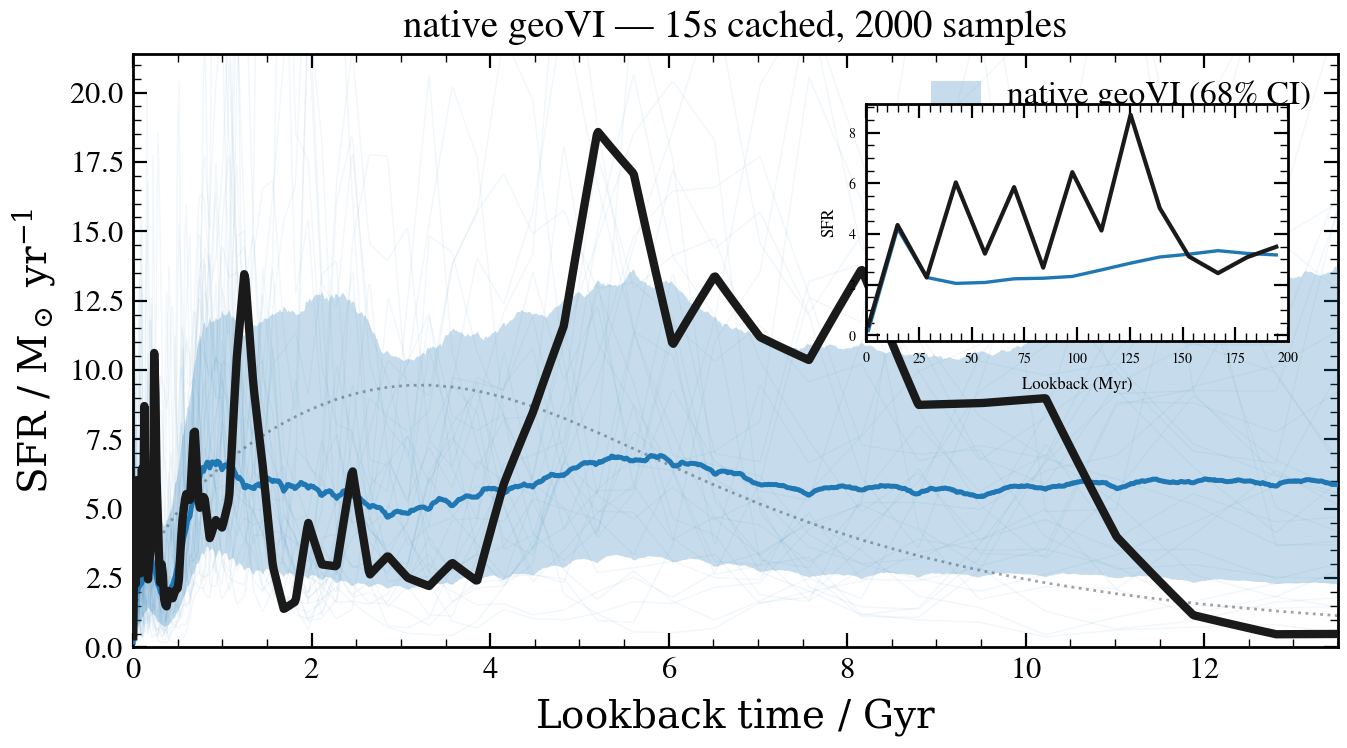

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_sfh(model, result_native_2, true_params=true_params, ax=ax,
         method="geoVI", label="native geoVI",
         color=COLORS["rt"])
ax.set_title(f"native geoVI — {t_native_cached:.0f}s cached, "
             f"{n_samples_native} samples")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_sfh_native.png"),
            dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site

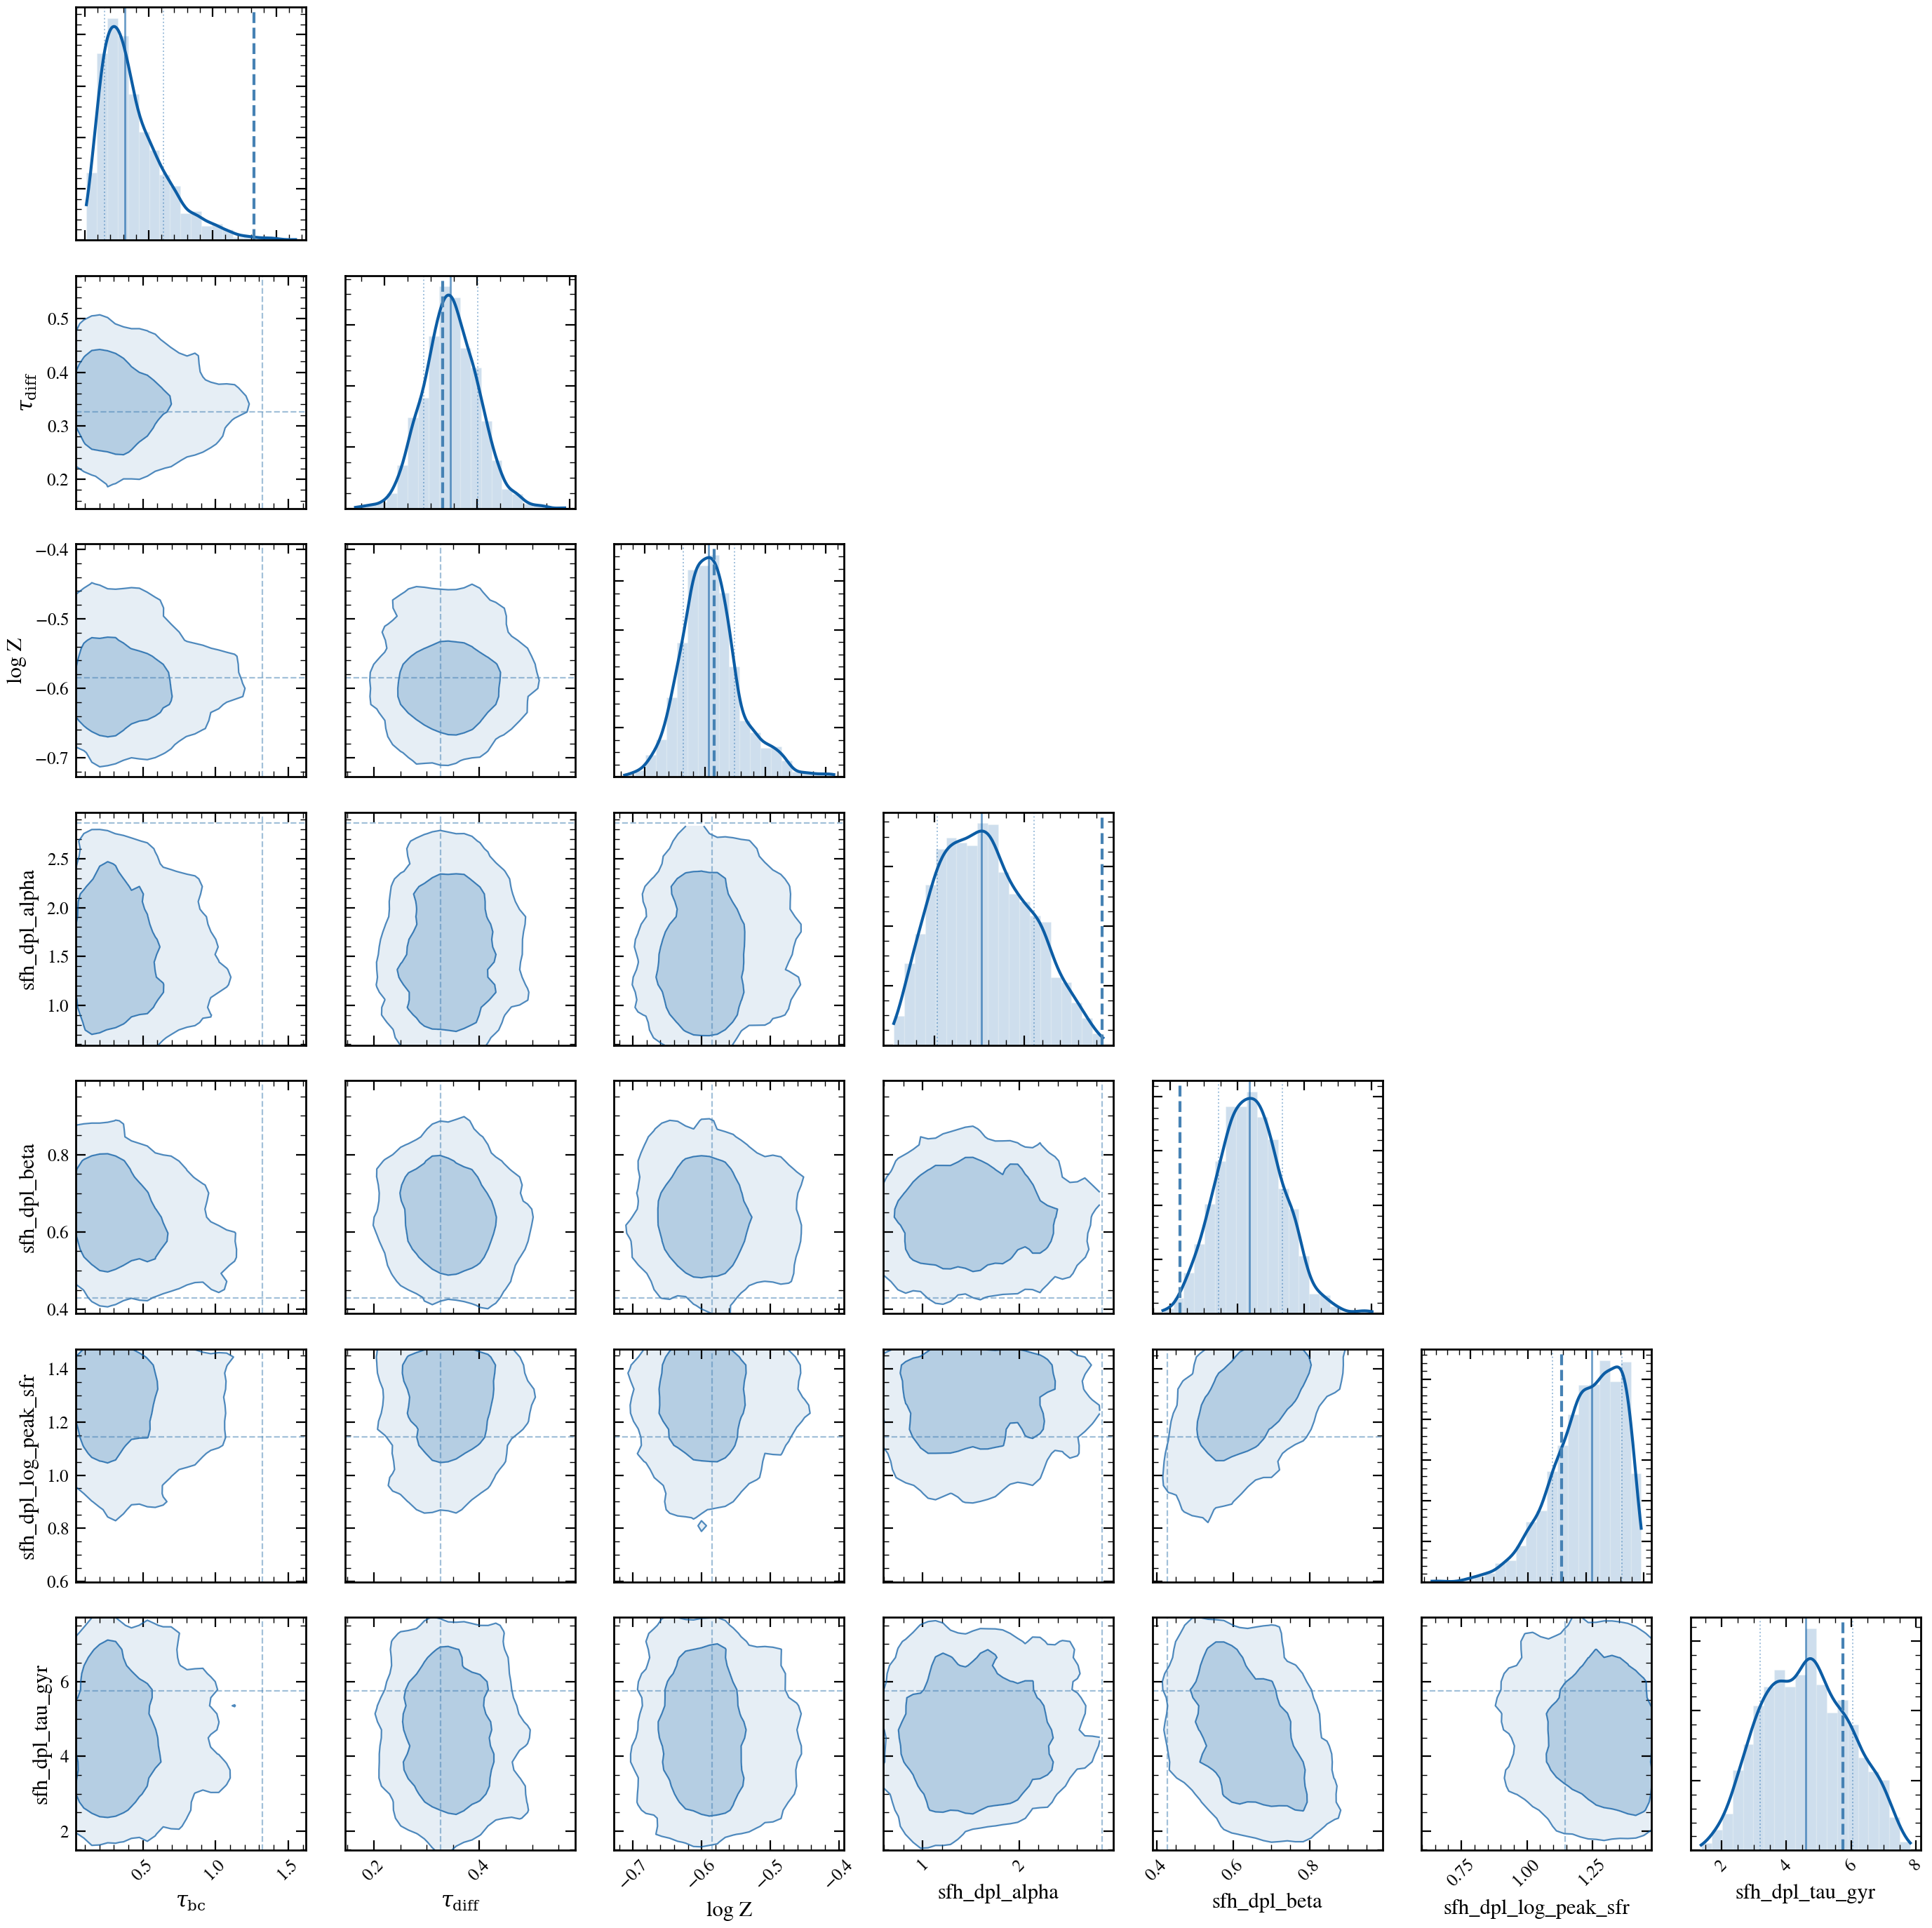

In [12]:
fig = safe_corner(result_native_2, truths=true_params)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "02_corner_native.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 5. Ray Tracing — exact MCMC (Behroozi 2025)

Stochastic-gradient resilient MCMC. Provides exact posterior
samples (no variational approximation). Slower mixing for
spectroscopy (tight likelihood → small step_size needed).

In [13]:
# MAP initialization for RT
t0 = time.perf_counter()
result_map = fitter.run("map", n_steps=1000, verbose=False)
t_map = time.perf_counter() - t0

# Ray Tracing
# step_size=0.002 for spectroscopy (40x smaller than photometry)
t0 = time.perf_counter()
result_rt = fitter.run(
    "raytrace",
    init_from=result_map,
    step_size=0.002,
    n_leapfrog_steps=50,
    n_burnin=200,
    n_steps=2000,
    verbose=True,
)
t_rt = time.perf_counter() - t0
n_samples_rt = len(next(iter(result_rt.samples.values())))
accept = result_rt.diagnostics.get("accept_rate", 0)
print(f"\nRay Tracing: {t_rt:.1f}s, {n_samples_rt} samples, "
      f"accept={accept:.1%}")

Ray Tracing: 135 params, 200 burn-in + 2000 samples, 50 leapfrog/step, step_size=0.0020
  Ray Tracing complete in 0.7s. Acceptance: 97.9% (overall), 98.0% (post burn-in). Samples: 2000

Ray Tracing: 9.9s, 2000 samples, accept=97.9%


### 5a. RT convergence

In [14]:
print("tengri check_convergence (RT):")
result_rt.check_convergence(verbose=True)

tengri check_convergence (RT):
Parameter               τ (std)  τ (abs)  τ (max)      ESS  Conv?
-----------------------------------------------------------------
dust_tau_bc              2473.4   1206.8   2473.4        1   WARN
dust_tau_diff             794.4     49.8    794.4        3   WARN
met_logzsol                27.9      3.1     27.9       72     OK
sfh_dpl_alpha            1449.3    427.2   1449.3        1   WARN
sfh_dpl_beta             1750.4    879.8   1750.4        1   WARN
sfh_dpl_log_peak_sfr     1598.2    816.8   1598.2        1   WARN
sfh_dpl_tau_gyr          1922.3   1048.7   1922.3        1   WARN

  >> dust_tau_bc: τ=2473.4 but need N > 5τ = 12367 (have N=2000). Autocorrelation time is likely underestimated.
  >> dust_tau_diff: τ=794.4 but need N > 5τ = 3972 (have N=2000). Autocorrelation time is likely underestimated.
  >> sfh_dpl_alpha: τ=1449.3 but need N > 5τ = 7246 (have N=2000). Autocorrelation time is likely underestimated.
  >> sfh_dpl_beta: τ=1750.4 but ne

{'all_converged': False,
 'params': {'dust_tau_bc': {'tau_standard': 2473.3856577467736,
   'tau_absolute': 1206.834169283786,
   'tau_max': 2473.3856577467736,
   'ess': 0.8086082304778857,
   'chain_converged': False},
  'dust_tau_diff': {'tau_standard': 794.3847473195665,
   'tau_absolute': 49.820991884673134,
   'tau_max': 794.3847473195665,
   'ess': 2.5176717034767493,
   'chain_converged': False},
  'met_logzsol': {'tau_standard': 27.850281210543464,
   'tau_absolute': 3.096233393809222,
   'tau_max': 27.850281210543464,
   'ess': 71.81256034293997,
   'chain_converged': True},
  'sfh_dpl_alpha': {'tau_standard': 1449.2793416451732,
   'tau_absolute': 427.19275461002974,
   'tau_max': 1449.2793416451732,
   'ess': 1.3799962108958699,
   'chain_converged': False},
  'sfh_dpl_beta': {'tau_standard': 1750.4235919877278,
   'tau_absolute': 879.8335670326488,
   'tau_max': 1750.4235919877278,
   'ess': 1.142580578298114,
   'chain_converged': False},
  'sfh_dpl_log_peak_sfr': {'tau_s

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_61886/86176819.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


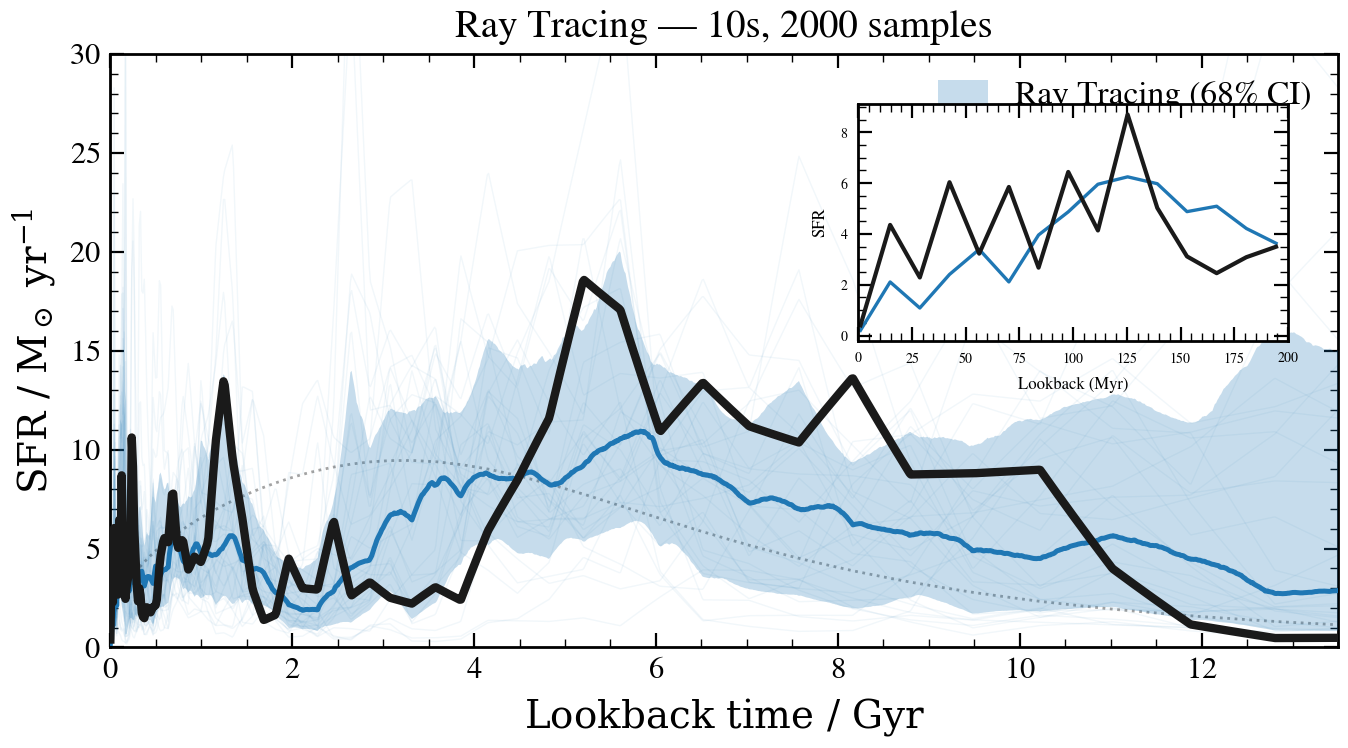

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_sfh(model, result_rt, true_params=true_params, ax=ax,
         method="RT", label="Ray Tracing")
ax.set_title(f"Ray Tracing — {t_rt:.0f}s, {n_samples_rt} samples")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_sfh_rt.png"),
            dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site

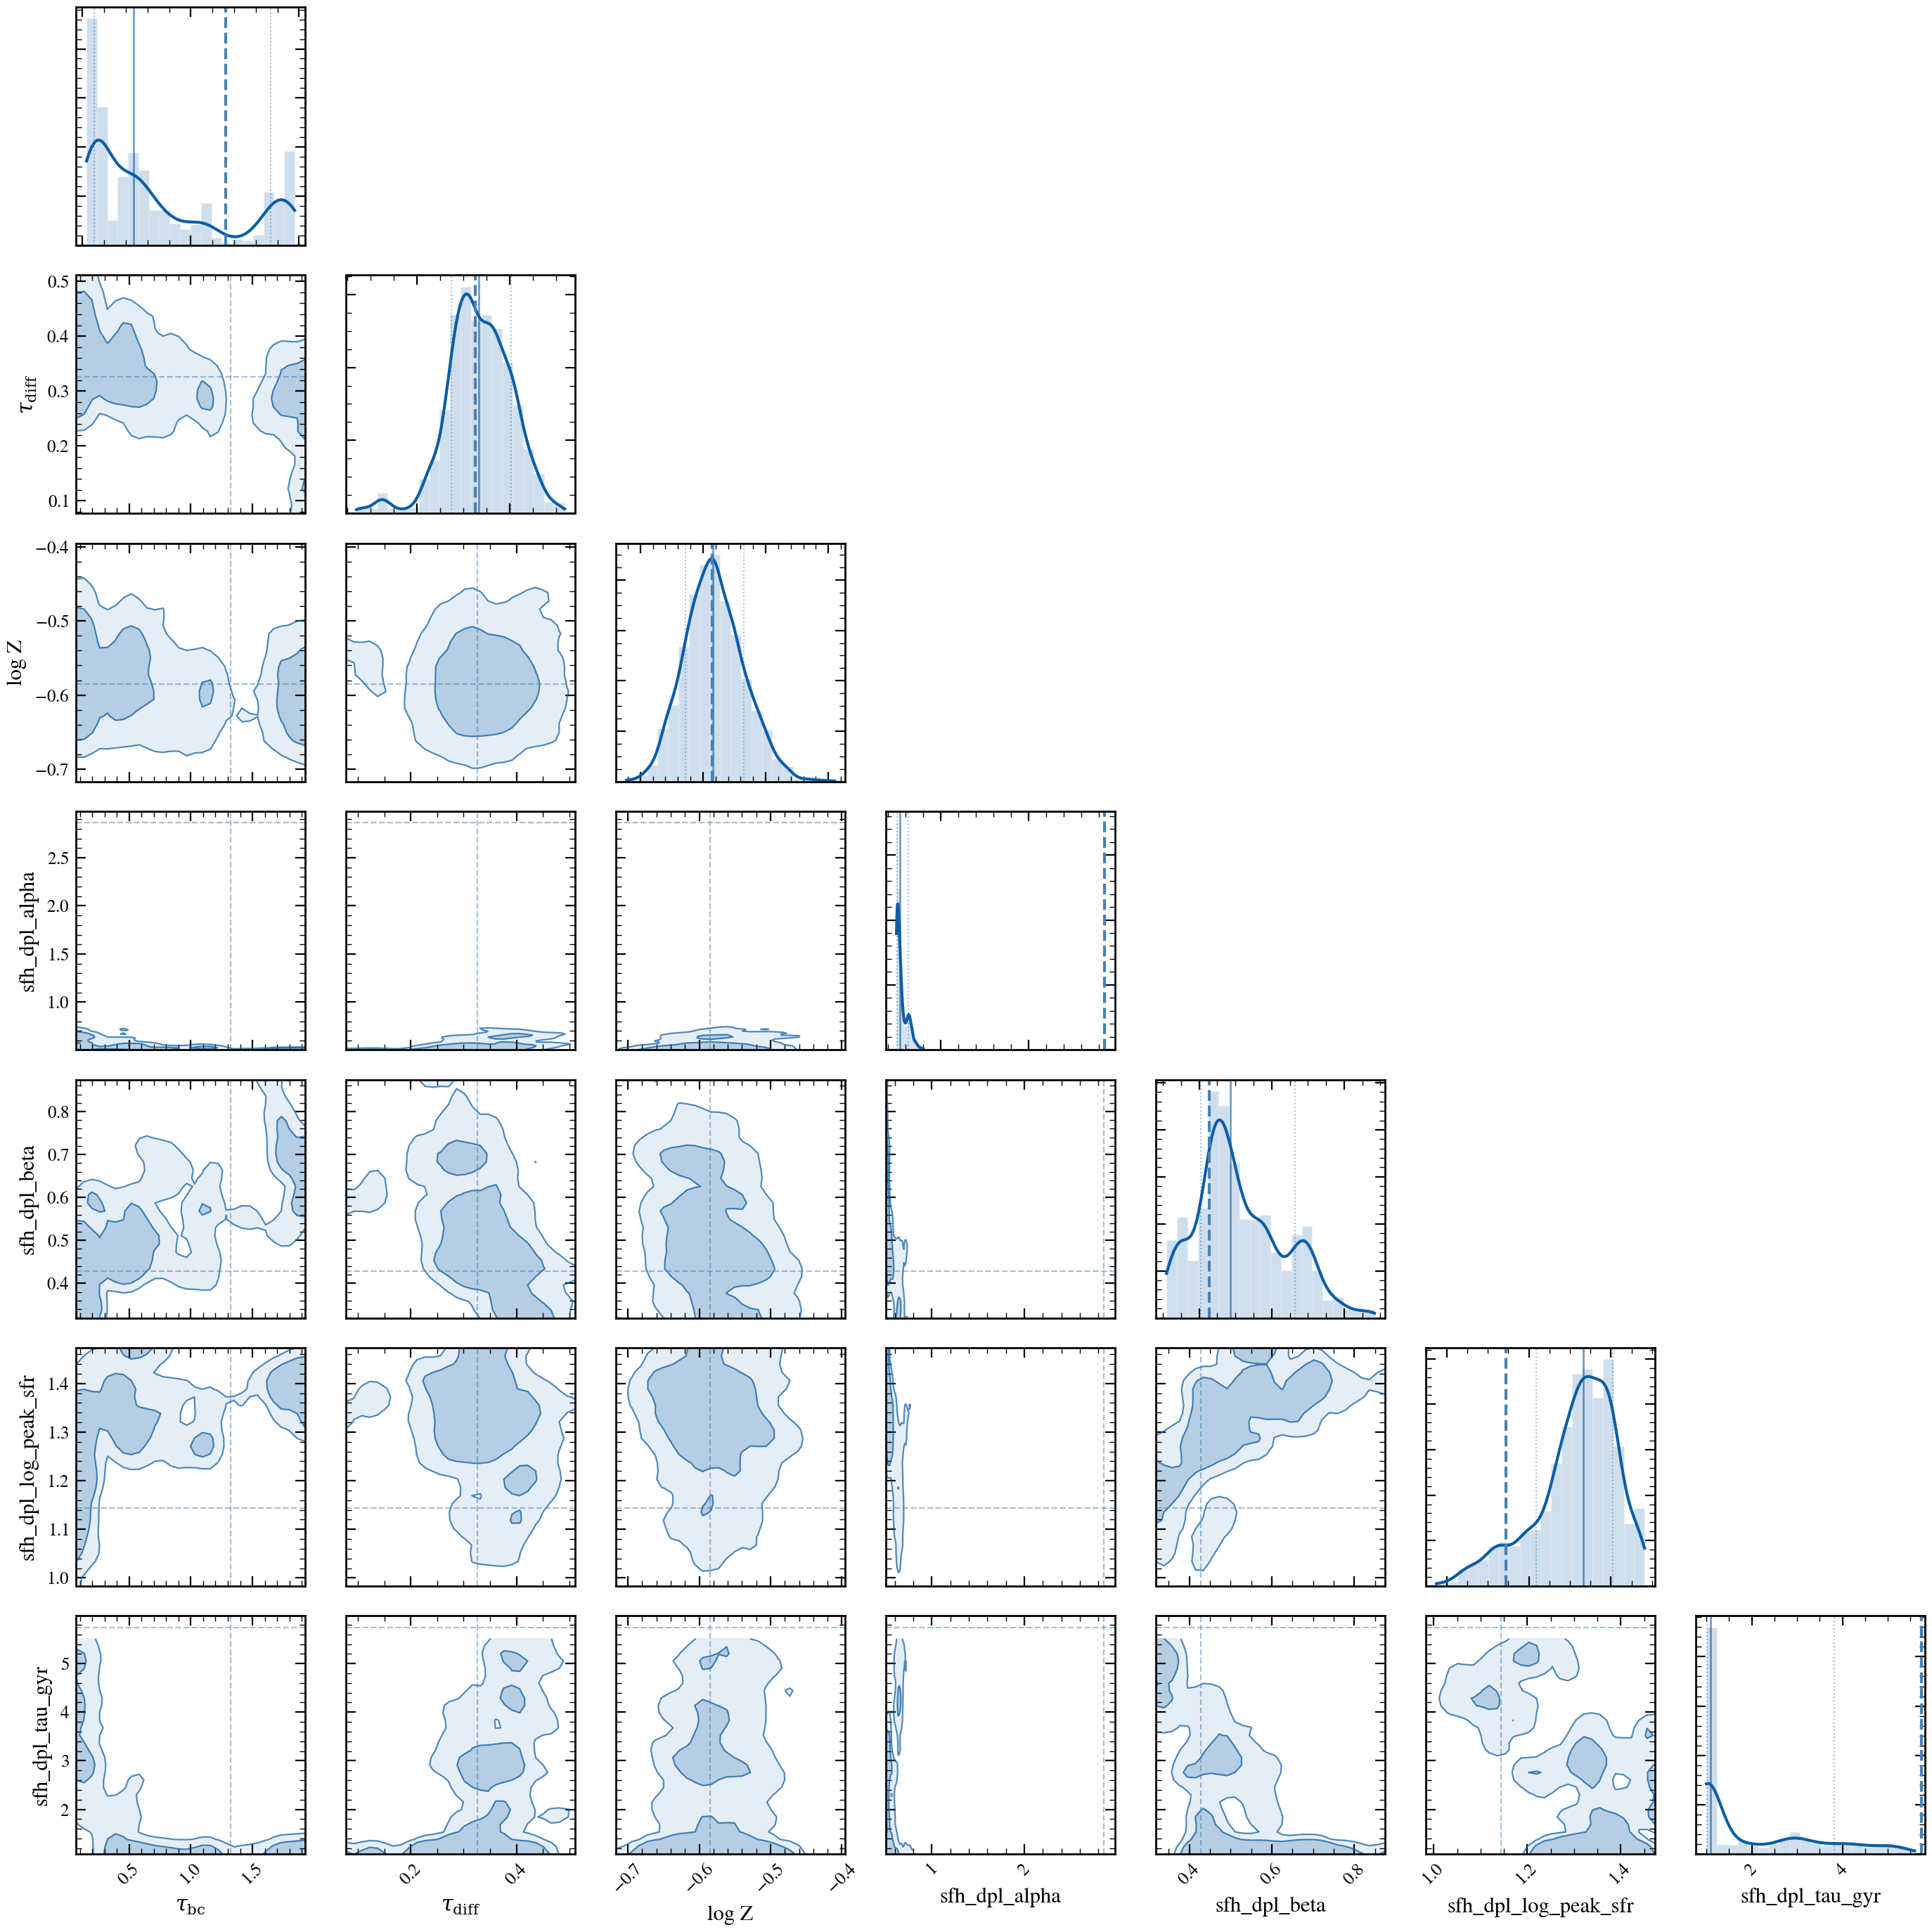

In [16]:
fig = safe_corner(result_rt, truths=true_params)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "02_corner_rt.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 6. Three-way comparison

### 6a. SFH recovery

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_61886/1620256419.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


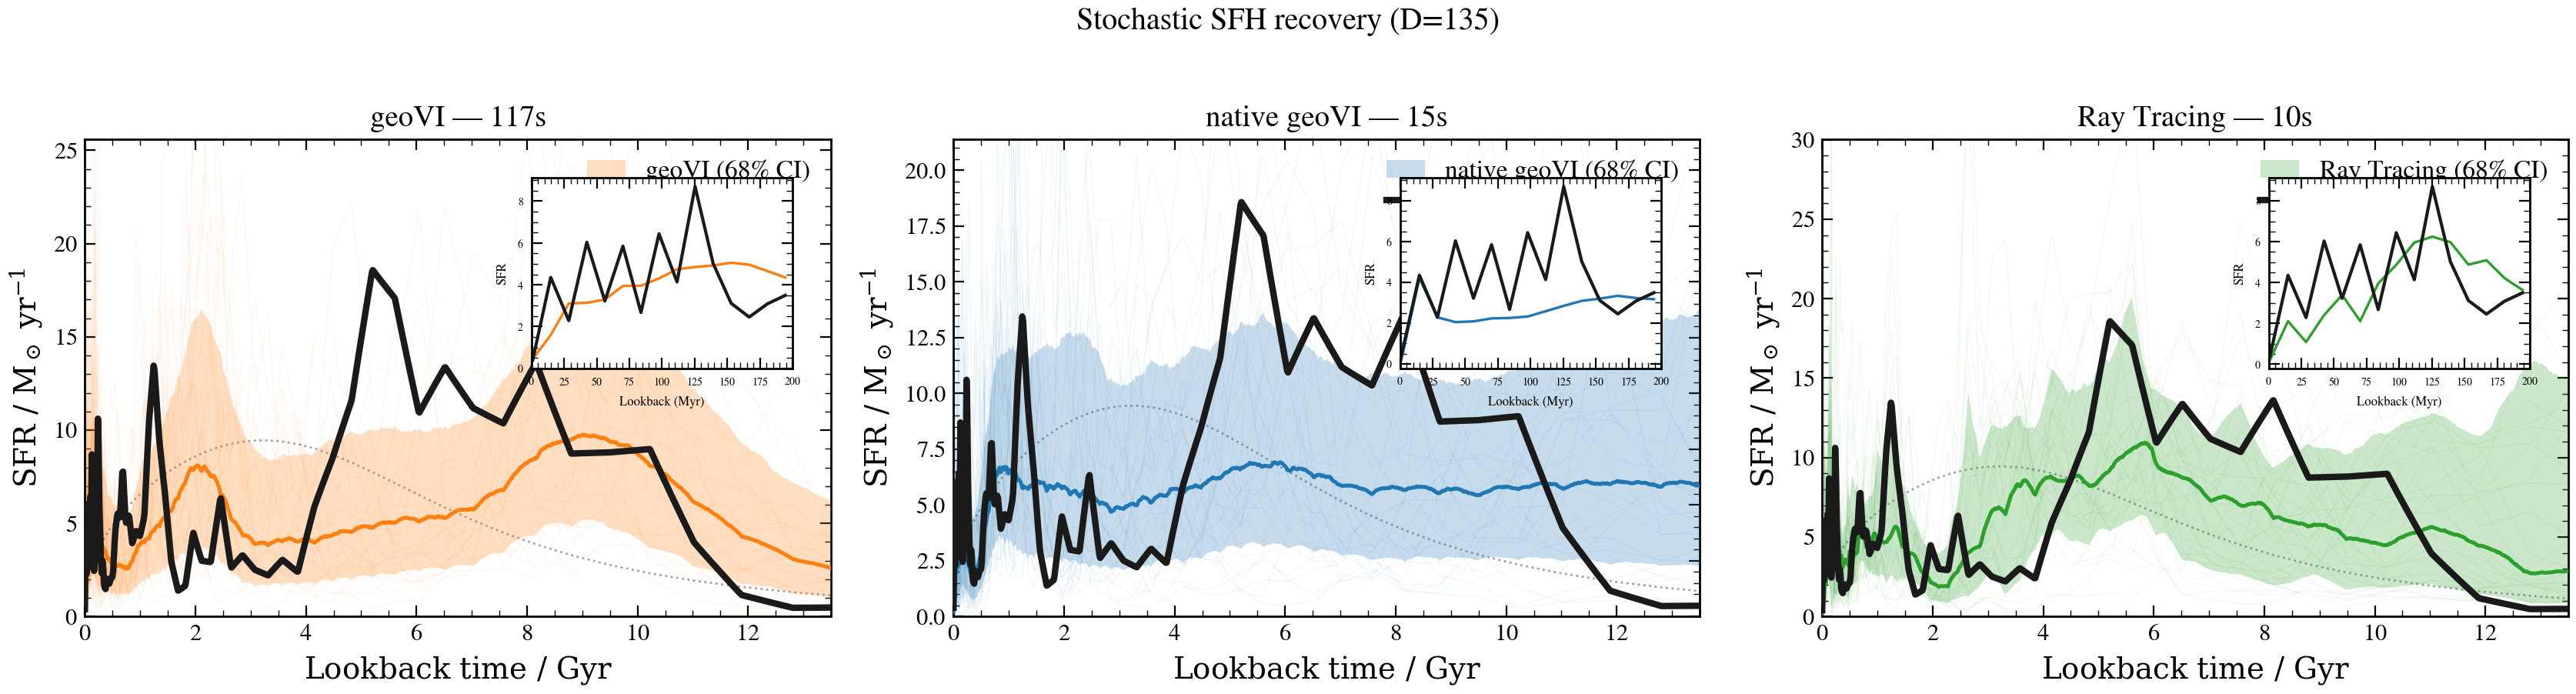

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, result, label, color, t, ns in [
    (axes[0], result_geovi, "geoVI", COLORS["geovi"],
     t_geovi, n_samples_geovi),
    (axes[1], result_native_2, "native geoVI", COLORS["rt"],
     t_native_cached, n_samples_native),
    (axes[2], result_rt, "Ray Tracing", COLORS["nuts"],
     t_rt, n_samples_rt),
]:
    plot_sfh(model, result, true_params=true_params, ax=ax,
             color=color, label=label)
    ax.set_title(f"{label} — {t:.0f}s")

fig.suptitle(f"Stochastic SFH recovery (D={D})", y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_sfh_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### 6b. Corner overlay (geoVI vs native vs RT)

/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site

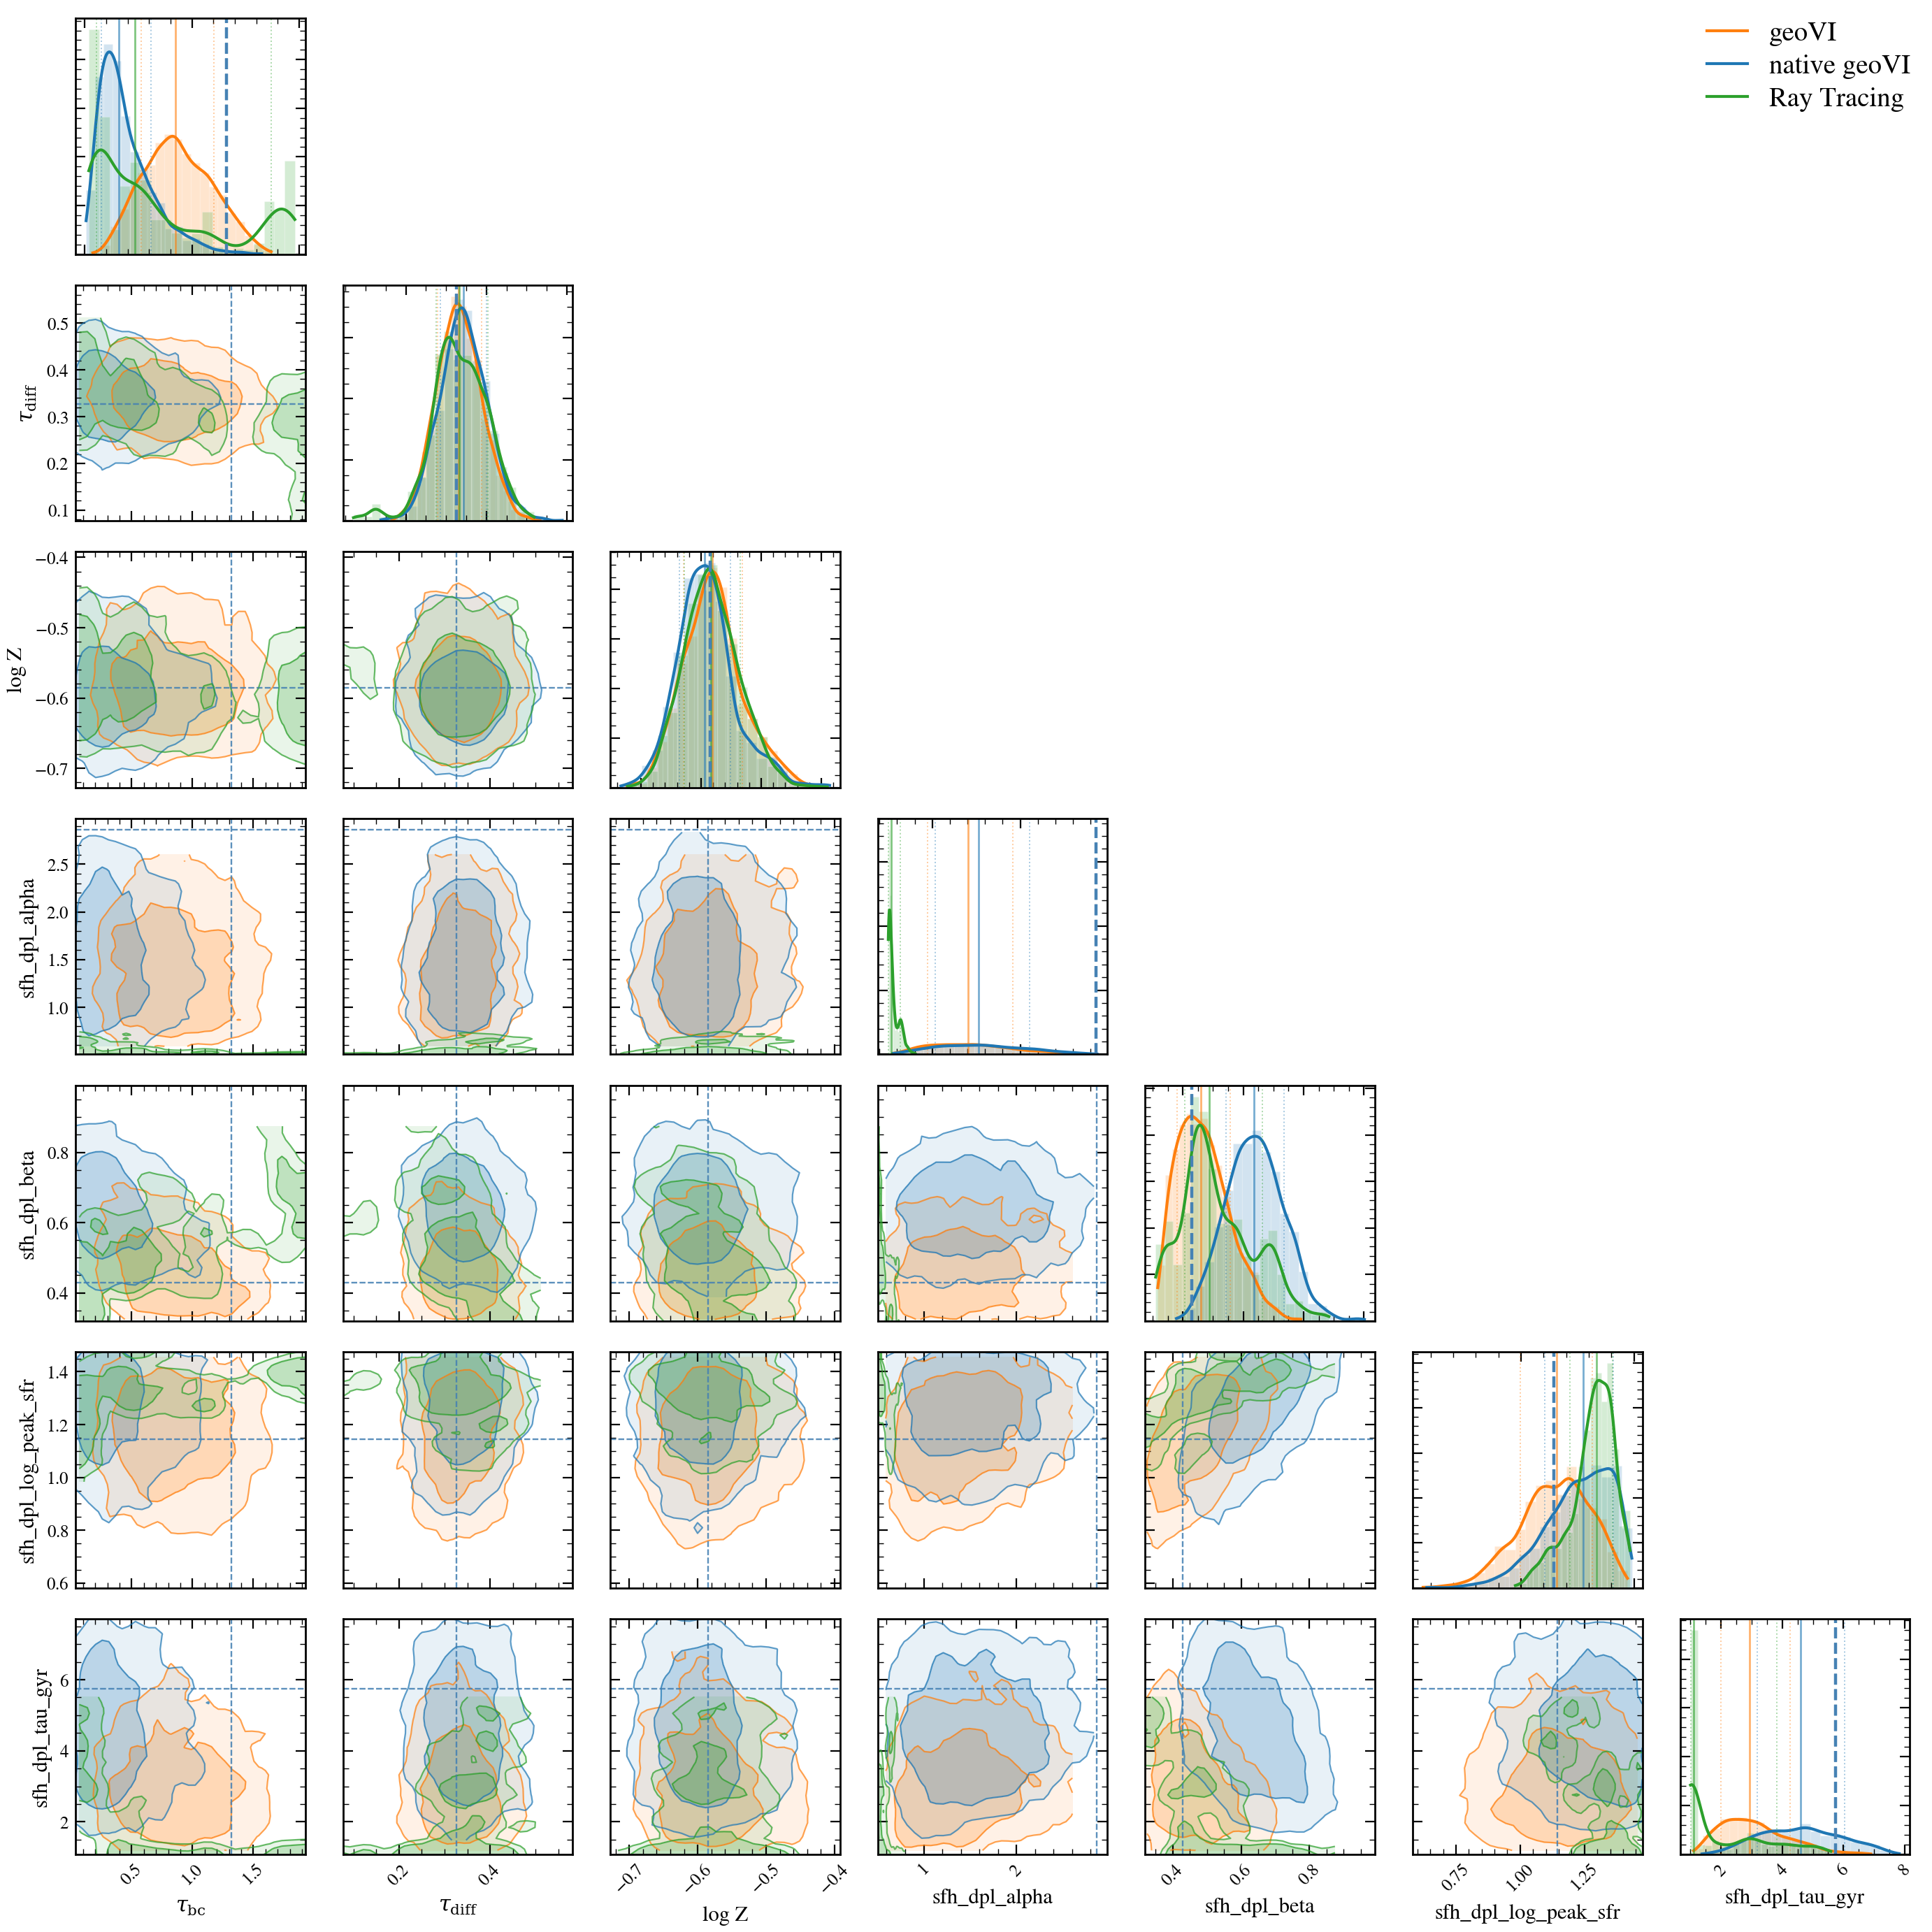

In [18]:
fig = plot_corner_comparison(
    [result_geovi, result_native_2, result_rt],
    labels=["geoVI", "native geoVI", "Ray Tracing"],
    colors=[COLORS["geovi"], COLORS["rt"], COLORS["nuts"]],
    truths=true_params,
)
if fig is not None:
    fig.savefig(os.path.join(FIGDIR, "02_corner_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

### 6c. Spectrum fits

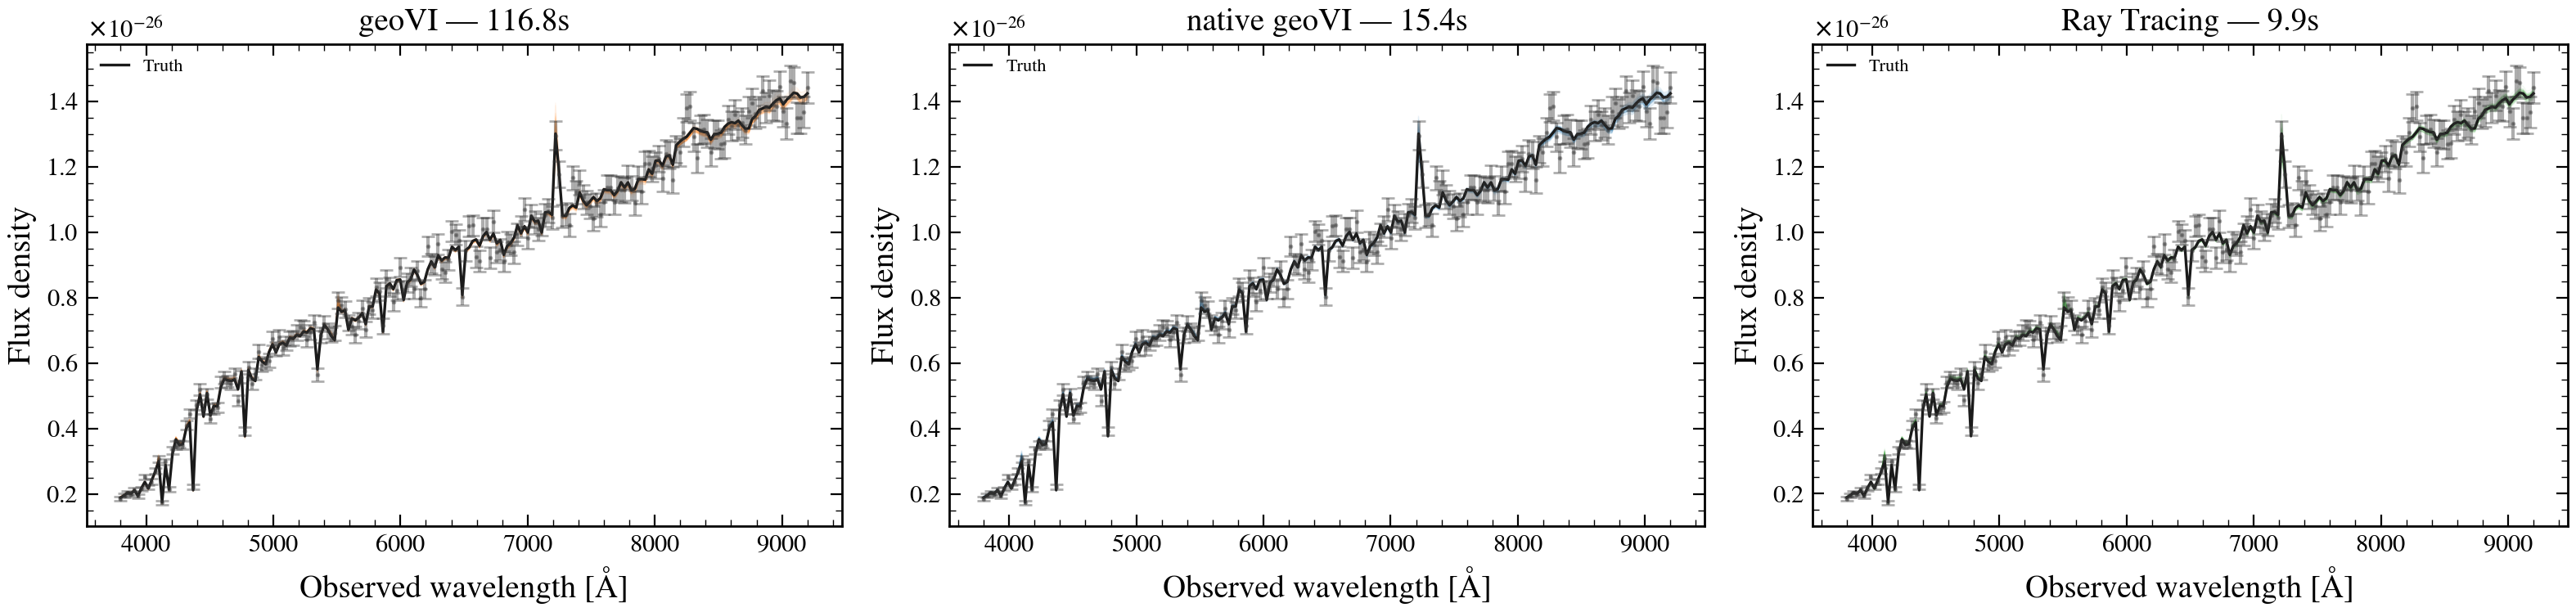

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, result, label, color, t in [
    (axes[0], result_geovi, "geoVI", COLORS["geovi"], t_geovi),
    (axes[1], result_native_2, "native geoVI", COLORS["rt"],
     t_native_cached),
    (axes[2], result_rt, "Ray Tracing", COLORS["nuts"], t_rt),
]:
    s = result.samples
    nd = min(50, len(list(s.values())[0]))
    for j in range(nd):
        draw = {k: v[j] for k, v in s.items()}
        pred = model.predict_spectrum(draw, WAVE_OBS)
        ax.plot(np.array(WAVE_OBS), np.array(pred),
                color=color, alpha=0.06, lw=0.5)
    ax.errorbar(np.array(WAVE_OBS), np.array(mock.flux_obs),
                yerr=np.array(mock.noise), fmt=".", ms=2,
                color=COLORS["data"], alpha=0.4, zorder=5)
    ax.plot(np.array(WAVE_OBS), np.array(mock.flux_true),
            color=COLORS["truth"], lw=1.2, label="Truth")
    ax.set_xlabel("Observed wavelength [Å]")
    ax.set_ylabel("Flux density")
    ax.set_title(f"{label} — {t:.1f}s")
    ax.legend(fontsize=8)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_spectrum_fit.png"), dpi=150)
plt.show()

## 7. Batch: 10 galaxies — native_geovi

Engine cached on Model from §4. Each new Fitter reuses it.

In [20]:
N_BATCH = 10
batch_keys = jax.random.split(jax.random.PRNGKey(777), N_BATCH)

batch_mocks = []
batch_truths = []
for bk in batch_keys:
    true_i = spec.sample(bk)
    mock_i = model.mock_spectrum(true_i, WAVE_OBS, snr=30.0, key=bk)
    batch_mocks.append(mock_i)
    batch_truths.append(true_i)

In [21]:
times_batch = []
results_batch = []

for i, (mock_i, bk) in enumerate(zip(batch_mocks, batch_keys)):
    f_i = Fitter(model, mock_i.flux_obs, mock_i.noise)
    t0 = time.perf_counter()
    r_i = f_i.run("native_geovi", n_iterations=15, n_seeds=1,
                   key=bk, verbose=False)
    dt = time.perf_counter() - t0
    times_batch.append(dt)
    results_batch.append(r_i)
    print(f"  Galaxy {i+1:>2d}: {dt:.1f}s")

  Galaxy  1: 14.2s
  Galaxy  2: 14.5s
  Galaxy  3: 17.1s
  Galaxy  4: 14.8s
  Galaxy  5: 13.8s
  Galaxy  6: 17.7s
  Galaxy  7: 15.4s
  Galaxy  8: 14.8s
  Galaxy  9: 13.9s
  Galaxy 10: 14.4s


In [22]:
print("\n" + "=" * 50)
print(f"Batch {N_BATCH} galaxies — native_geovi (MAP init)")
print("-" * 50)
print(f"Compile (1st call, §4):        {t_native_compile:.1f}s")
print(f"Per galaxy (cached):           {np.mean(times_batch):.1f}s")
print(f"Total ({N_BATCH} galaxies):           "
      f"{np.sum(times_batch):.0f}s")
amort = (t_native_compile + np.sum(times_batch)) / (N_BATCH + 1)
print(f"Amortized (incl compile):      {amort:.1f}s")
print("=" * 50)


Batch 10 galaxies — native_geovi (MAP init)
--------------------------------------------------
Compile (1st call, §4):        17.2s
Per galaxy (cached):           15.1s
Total (10 galaxies):           151s
Amortized (incl compile):      15.3s


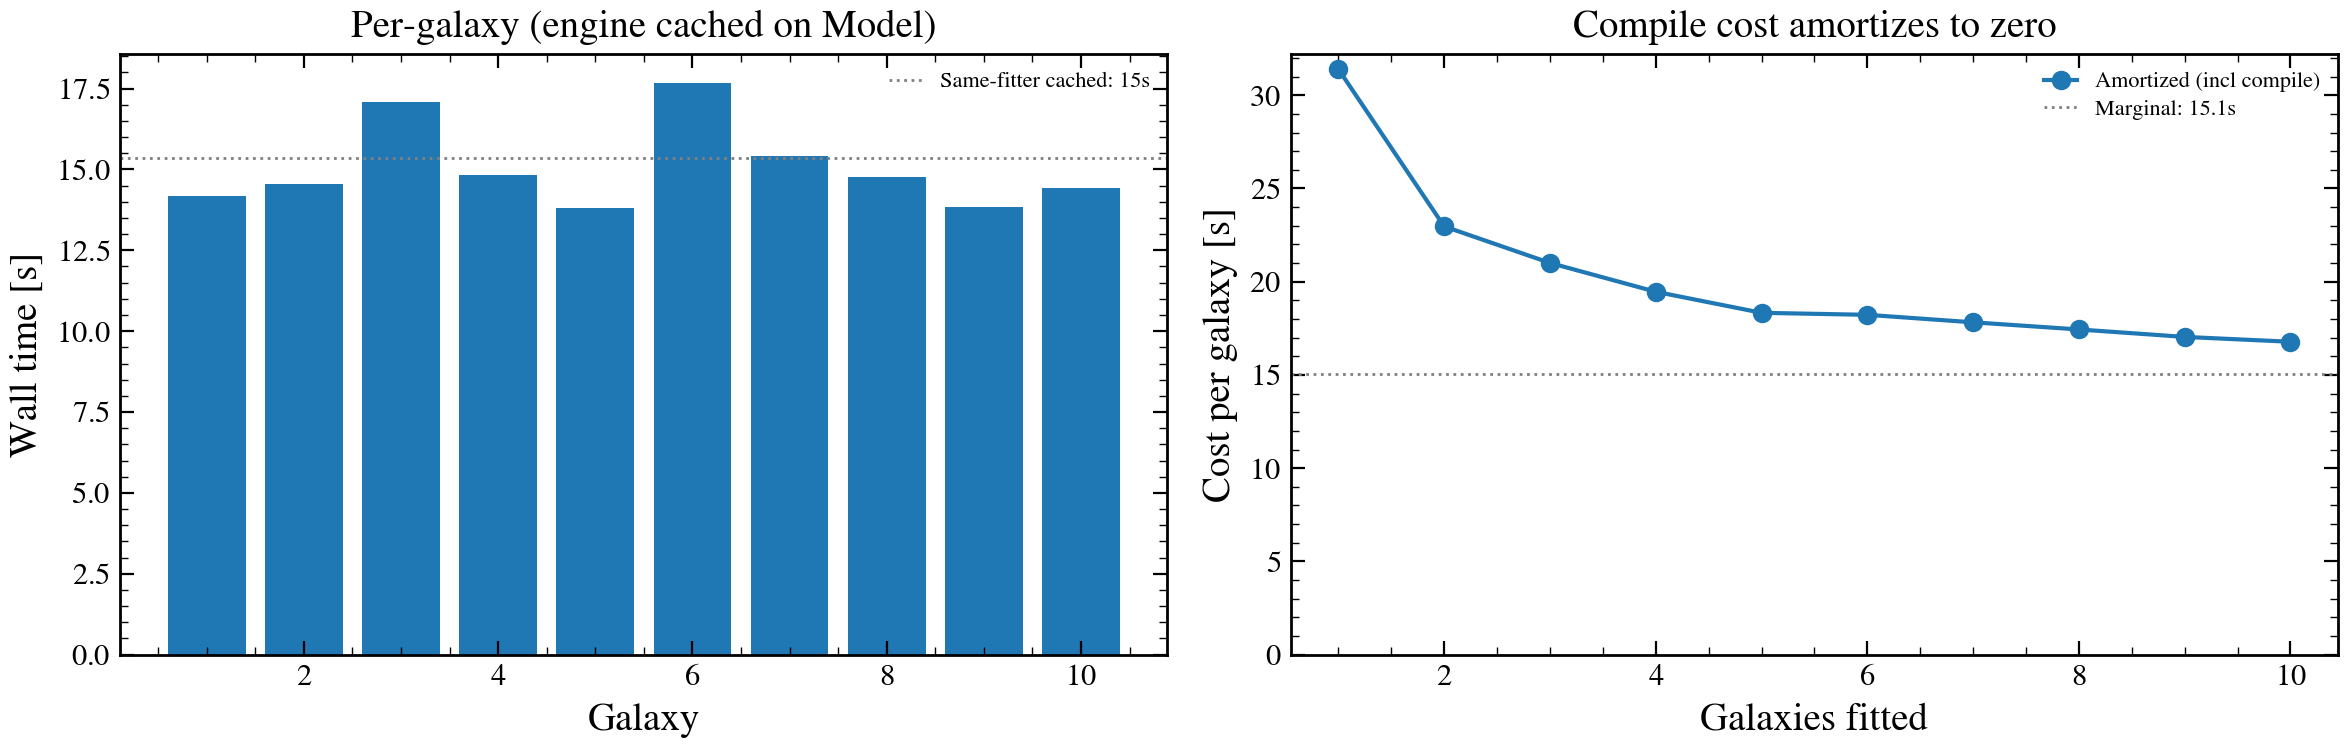

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, N_BATCH + 1), times_batch, color=COLORS["rt"])
ax1.axhline(t_native_cached, color="grey", ls=":", lw=1,
            label=f"Same-fitter cached: {t_native_cached:.0f}s")
ax1.set_xlabel("Galaxy")
ax1.set_ylabel("Wall time [s]")
ax1.set_title("Per-galaxy (engine cached on Model)")
ax1.legend(fontsize=8)

cum = np.cumsum(times_batch)
amort_curve = (t_native_compile + cum) / np.arange(1, N_BATCH + 1)
ax2.plot(range(1, N_BATCH + 1), amort_curve, "o-", color=COLORS["rt"],
         label="Amortized (incl compile)")
ax2.axhline(np.mean(times_batch), color="grey", ls=":", lw=1,
            label=f"Marginal: {np.mean(times_batch):.1f}s")
ax2.set_xlabel("Galaxies fitted")
ax2.set_ylabel("Cost per galaxy [s]")
ax2.set_title("Compile cost amortizes to zero")
ax2.legend(fontsize=8)
ax2.set_ylim(0, None)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_batch_timing.png"), dpi=150)
plt.show()

### 7a. Batch SFH gallery

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_61886/2114656424.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


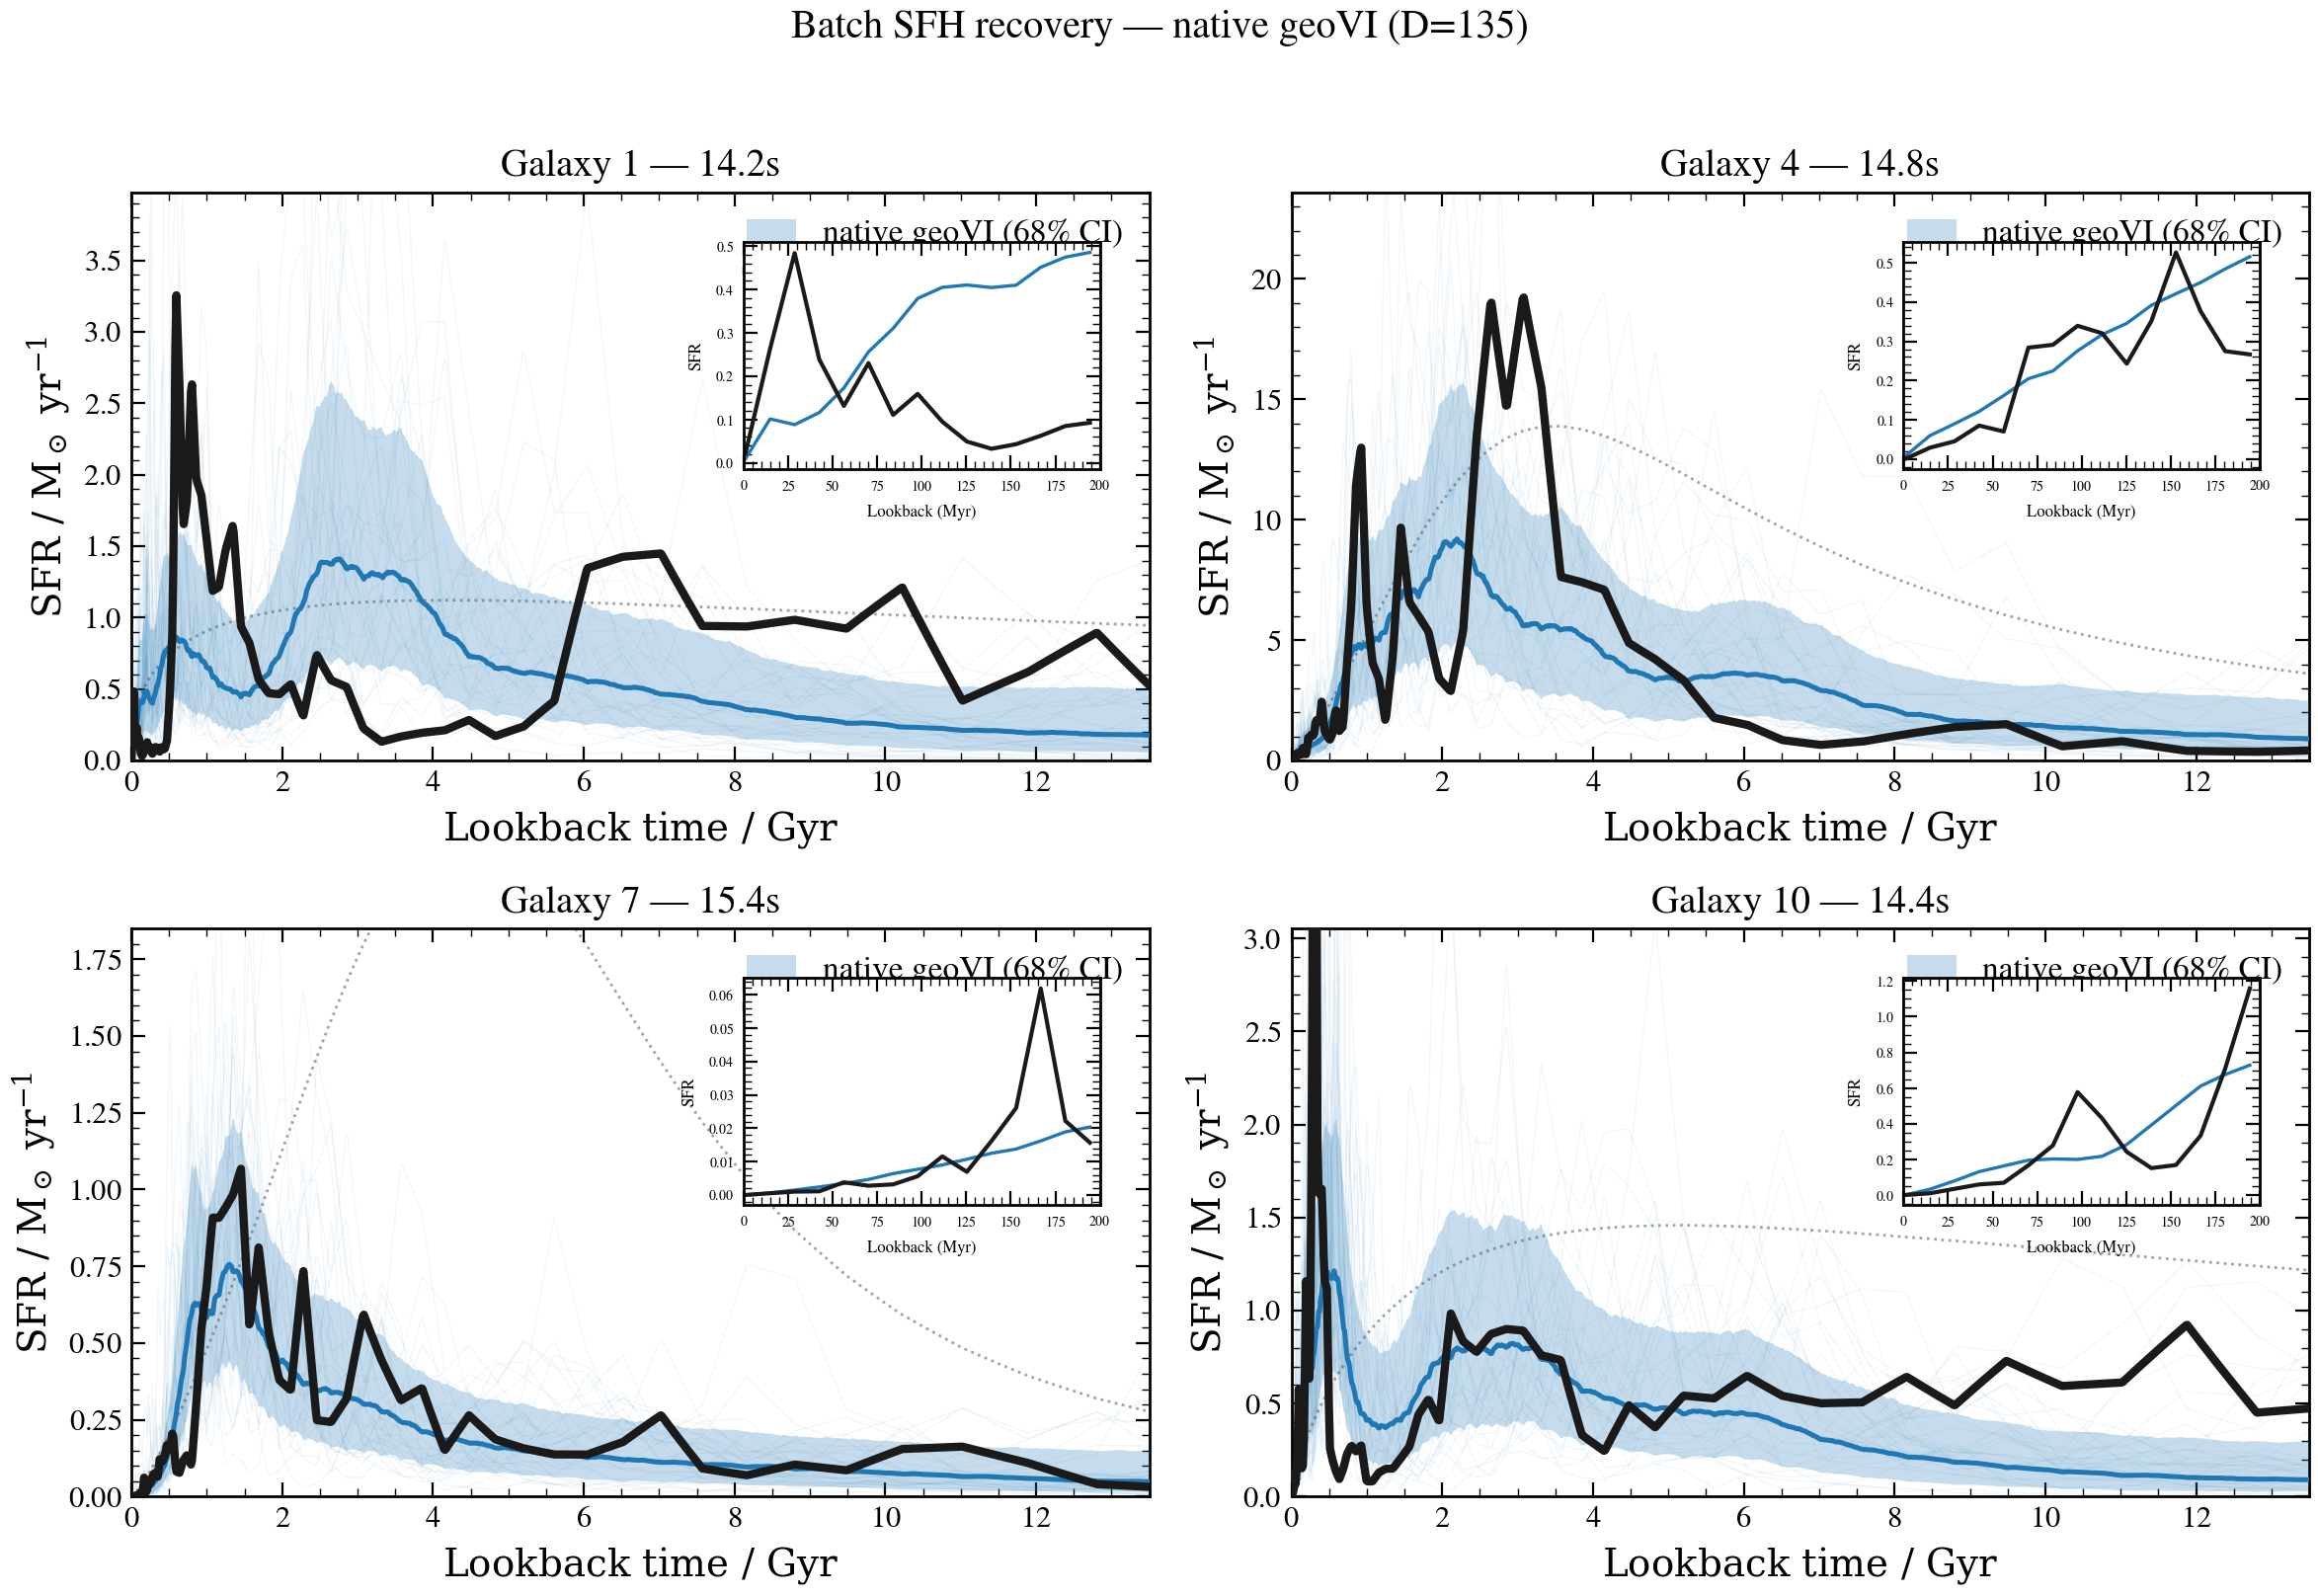

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
show_idx = [0, 3, 6, 9]

for ax, idx in zip(axes.flatten(), show_idx):
    plot_sfh(model, results_batch[idx],
             true_params=batch_truths[idx], ax=ax,
             method="geoVI", label="native geoVI",
             color=COLORS["rt"])
    ax.set_title(f"Galaxy {idx+1} — {times_batch[idx]:.1f}s")

fig.suptitle(f"Batch SFH recovery — native geoVI (D={D})", y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "02_batch_sfh_gallery.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Timing summary

In [25]:
print("=" * 60)
print(f"{'Method':<30s} {'Time':>8s} {'Samples':>8s}")
print("-" * 60)
print(f"{'geoVI (NIFTy)':<30s} {t_geovi:>7.1f}s "
      f"{n_samples_geovi:>8d}")
print(f"{'native_geovi (compile)':<30s} "
      f"{t_native_compile:>7.1f}s {n_samples_native:>8d}")
print(f"{'native_geovi (cached)':<30s} "
      f"{t_native_cached:>7.1f}s {n_samples_native:>8d}")
print(f"{'Ray Tracing':<30s} {t_rt:>7.1f}s "
      f"{n_samples_rt:>8d}")
print("-" * 60)
print(f"{'Batch 10 (mean/galaxy)':<30s} "
      f"{np.mean(times_batch):>7.1f}s")
print(f"{'Batch 10 (total)':<30s} "
      f"{np.sum(times_batch):>7.0f}s")
print("=" * 60)

Method                             Time  Samples
------------------------------------------------------------
geoVI (NIFTy)                    116.8s     2000
native_geovi (compile)            17.2s     2000
native_geovi (cached)             15.4s     2000
Ray Tracing                        9.9s     2000
------------------------------------------------------------
Batch 10 (mean/galaxy)            15.1s
Batch 10 (total)                   151s
